# $\color{orange}{\text{Chapter 5 of "Statistical Physics"}}$
# $\color{orange}{\textit{Einstein and Debye theory for the energy, specific heat and entropy of the vibrations in solids (quantized by means of the concept of phonons)}}$

Information about phonons on Wiki: https://en.wikipedia.org/wiki/Phonon

Specific heat $C_V$ in units $3 N k$

Entropy $S$ in units $3 N k$

Entropy is computed in Problem 3.3 during the problem sessions


Jan Ryckebusch (Version with Numpy: October 2022)


In [25]:
import matplotlib.pyplot as plt # matplotlib: nice & quick figures
import numpy as np

# colors and linestyles for the figures
colors=['mediumslateblue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan','khaki','fuchsia','gold','tomato','darkolivegreen','indigo','mediumvioletred']
linestyles = ['-', '--', '-.', ':','-', '--', '-.', ':','-', '--', '-.', ':','-', '--', '-.', ':','-']
# tweak the parameters of the plots: makes things look nicer ...
params = {'legend.fontsize' : 20,
          'axes.linewidth'  : 2.5,
          'axes.labelsize'  : 20,
          'lines.linewidth' : 2,
          'xtick.major.width' : 3,
          'xtick.major.size'  : 12,
          'ytick.major.width' : 3,
          'ytick.major.size'  : 12,
          'xtick.major.pad'  : 10,
          'xtick.minor.width' : 2,
          'xtick.minor.size'  : 6,
          'ytick.minor.width' : 2,
          'ytick.minor.size'  : 6,
          'xtick.labelsize'    : 18,
          'ytick.labelsize'    : 18 }
#plt.rcParams['text.latex.preamble']=[r"\usepackage{amsmath} \usepackage{amssymb} \usepackage{amsfonts} \boldmath"]
plt.rcParams.update(params)
plt.rc("font",family="serif",weight='bold')

# Harmonische-oscillator vrijheidsgraad in een warmtebad

Gemiddelde energie: $\overline{\epsilon} = \frac {1} {2} \hbar \omega _E + \frac {\hbar \omega_E} {\exp
\left( \beta \hbar \omega _E \right) -1}$ (nulpuntsenergie + $T$-afhankelijke contributie)

Dimensieloze grootheid: $x_E = \beta \hbar \omega_E$

Partitiefunctie van een eendimensionale HO in warmtebad: $Z_1(T,V) = \frac{1}{2 \sinh \left( \frac{x_E}{2} \right)}$

Gemiddelde bezetting $p_n$ van het energie-niveau $\epsilon _n = \hbar \omega \left( n + \frac {1} {2}\right)$:

$p_n = \exp \left(- n x _E \right) \left( 1 - \exp \left(- x_E \right) \right) $



<ipython-input-26-cc83c71c28af>:4: RuntimeWarning: overflow encountered in exp
  epsilon=0.5+np.divide(1,np.exp(1./xEmin)-1.)


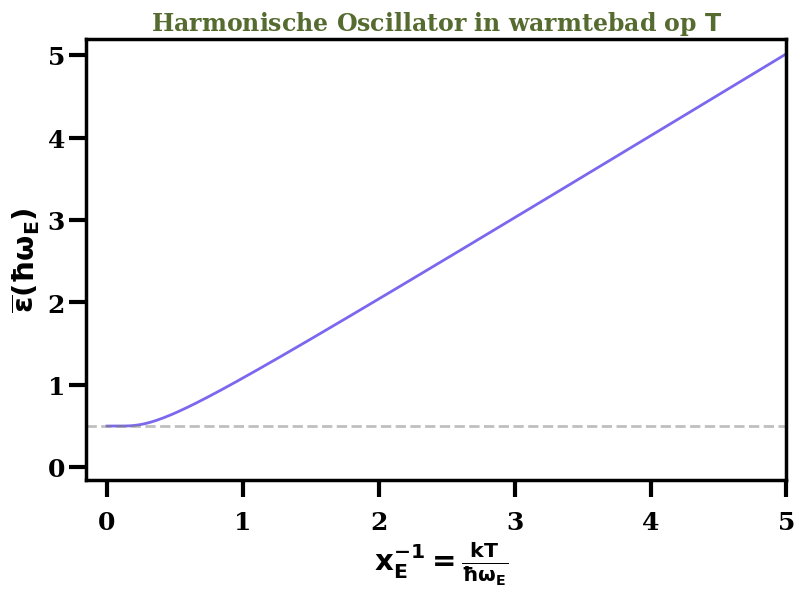

In [26]:
# figuur van gemiddelde energie van oscillator als functie van dimensieloze grootheden

xEmin=np.linspace(0.001,+5.0,num=300) # 1 over x = (kT)/(hbar \omega_E)
epsilon=0.5+np.divide(1,np.exp(1./xEmin)-1.)

figE = plt.figure(figsize=(10,7))
figE.subplots_adjust(bottom=0.25,left=0.2)
axE  = figE.add_subplot(111)

axE.plot(xEmin,epsilon,linestyle='-',linewidth=2,color='mediumslateblue')
axE.axhline(y=0.5,color='grey',linestyle='dashed',alpha=0.5) # 0.5 = grondtoestandsenergie
#
axE.set_ylabel(r"$\bf \overline{\epsilon} (\hbar \omega_E)$",fontsize=21,weight='bold')
axE.set_xlabel(r" $\bf x_E ^{-1} = \frac { k T}{\hbar \omega _E}$",fontsize=21,weight='bold')
axE.set_title(r"Harmonische Oscillator in warmtebad op $\bf T$",color='darkolivegreen',fontsize=17,weight='bold')
axE.set_ylim(-0.15,5.2) ; axE.set_xlim(-0.15,5.)
axE.locator_params(axis='x',nbins=7) # control the number of x-axis ticks
#ax1.legend(frameon=False,fontsize=22,ncol=1,loc='best')
figE.savefig("FigHOEnergy.eps")
figE.savefig("FigHOEnergy.pdf")
plt.show(figE)


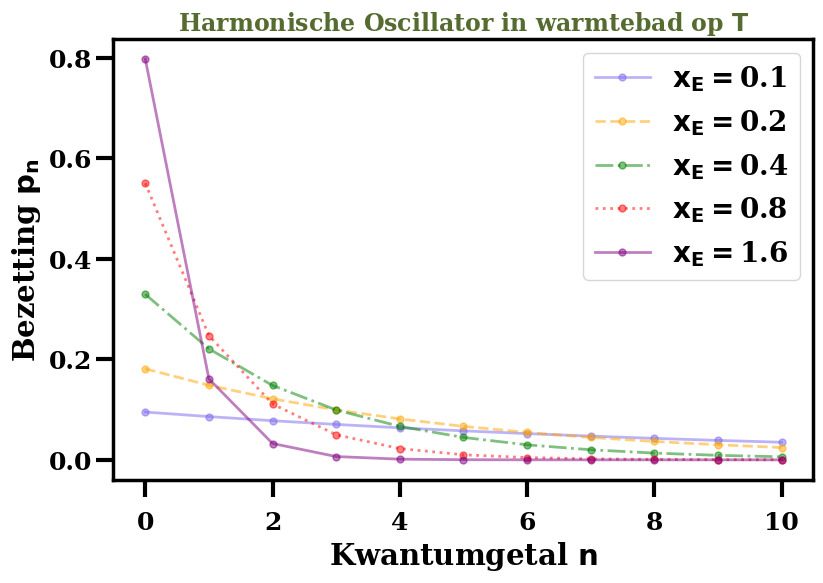

In [33]:
# figure with the occupation probabilities for range of values of n
values_of_n=np.arange(0,11,1,dtype=float)
listofxEs=[0.1,0.2,0.4,0.8,1.6]
figpn = plt.figure(figsize=(10,7))
figpn.subplots_adjust(bottom=0.25,left=0.2)
axpn  = figpn.add_subplot(111)
axpn.set_ylabel(r"Bezetting $\bf p_n$",fontsize=21,weight='bold')
axpn.set_xlabel(r"Kwantumgetal $\bf n$",fontsize=21,weight='bold')
axpn.set_title(r"Harmonische Oscillator in warmtebad op $\bf T$",color='darkolivegreen',fontsize=17,weight='bold')
for kk in range(len(listofxEs)):
  xE=listofxEs[kk]
  pn=np.exp(-xE*values_of_n)*(1-np.exp(-xE))
  axpn.plot(values_of_n,pn,linestyle=linestyles[kk],marker='o',markersize=5,alpha=0.5,linewidth=2,color=colors[kk],label=r'$\bf x_E=${0:}'.format(xE))

#
axpn.legend(loc='best')


#Coupled oscillators (Debye model) in the elastic limit: $C_V$ and $S$ are functions of $x_D$

Debye:
$
\frac {C_V} {3 N k} = \frac {3}
{x_D^3} \int _0 ^{x_D} \frac {x^4 e^x dx} {\left( e^x - 1 \right)^2 }
\; \; ; \; \;
\frac {S} {3 N k} = \frac {4}
{x_D^3} \int _0 ^{x_D} \frac {x^3 dx} {\left( e^x - 1 \right) }
- \ln \left( 1 - e^{-x_{D}} \right)
$

variable $x_D = \frac {\hbar \omega_D} {k T}$

$x_D = \frac {\Theta _D} {T}: \Theta _D$ is the Debye temperature

In [28]:
# xD is an numpy array with xD values :)
def CVdebye(xD):

  def debyeint(x):
    return np.multiply(np.power(x,4.),np.divide(np.exp(x),np.power(np.exp(x)-1.,2.)))

  integra=np.zeros_like(xD)

  for i in range(len(xD)):
    xint=np.linspace(0.001,xD[i],num=100,endpoint=True) # do not start at exactly zero (divergence in the denominator)
    integra[i]=np.trapz(debyeint(xint),dx=(xint[1]-xint[0])) # do the integral from 0 to x_D

  return np.multiply(np.divide(3.,np.power(xD,3.)),integra)

def Sdebye(xD):

  def Sdebyeint(x):
    return np.divide(np.power(x,3.),np.exp(x)-1.)

  integra=np.zeros_like(xD)

  for i in range(len(xD)):
    xint=np.linspace(0.001,xD[i],num=100,endpoint=True) # do not start at exactly zero (divergence in the denominator)
    integra[i]=np.trapz(Sdebyeint(xint),dx=(xint[1]-xint[0])) # do the integral from 0 to x_D

  return np.multiply(np.divide(4.,np.power(xD,3.)),integra)-np.log(1.-np.exp(-xD))

#Uncoupled oscillators (Einstein model): $C_V$ and $S$ are functions of  $x_E$

Einstein:
$
\frac {C_V} {3 N k} =  \frac {x_E^2 e ^{x_E} } {\left( e ^{x_E}  -1 \right)^2} \; \; ;  \; \;
\frac {S} {3 N k} = \frac {x_E} {\left( e ^{x_E}  -1 \right)} - \ln \left( 1 - e ^{- x_E}  \right)
$


Specific heat and entropy for a system of uncoupled oscillators with angular frequency $\omega_E$

variable $x_E = \frac {\hbar \omega_E} {k T}$

$x_E = \frac {\Theta _E} {T}: \Theta _E$ is the Einstein temperature

In [29]:
# xE is an numpy array
def CVeinstein(xE):
    return np.multiply(np.power(xE,2.),np.divide(np.exp(xE),np.power(np.exp(xE)-1.,2.)))

def Seinstein(xE):
    return np.divide(xE,(np.exp(xE)-1.))-np.log(1.-np.exp(-xE))


In [30]:
# compute the specific heat and entropy in the two models (uncoupled and coupled oscillators)

dT=0.02
TOVERTHETAD=np.arange(0.01,2.5+dT,dT) # start at small value above zero

CV3NK =np.zeros_like(TOVERTHETAD) # Debye C_V / (3Nk)
CV3NK2=np.zeros_like(TOVERTHETAD) # Einstein C_V / (3Nk)
CV3NK3=np.zeros_like(TOVERTHETAD) # (Einstein C_V) / (Debye C_V)

S3NK =np.zeros_like(TOVERTHETAD) # Debye S / (3Nk)
S3NK2=np.zeros_like(TOVERTHETAD) # Einstein S / (3Nk)
S3NK3=np.zeros_like(TOVERTHETAD) # (Einstein S) / (Debye S)


xx=np.divide(1.,TOVERTHETAD)      # theta_D / T ; theta_E / T

#

CV3NK2=CVeinstein(xx) ; S3NK2=Seinstein(xx) # Einstein
CV3NK =CVdebye(xx)    ; S3NK =Sdebye(xx) # Debye
CV3NK3=np.divide(CV3NK2,CV3NK) ; S3NK3=np.divide(S3NK2,S3NK) # ratio of the two


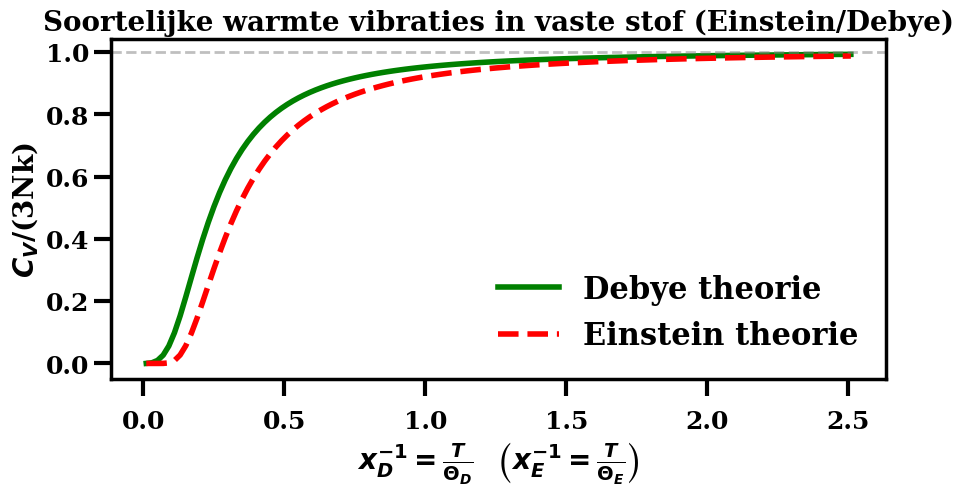

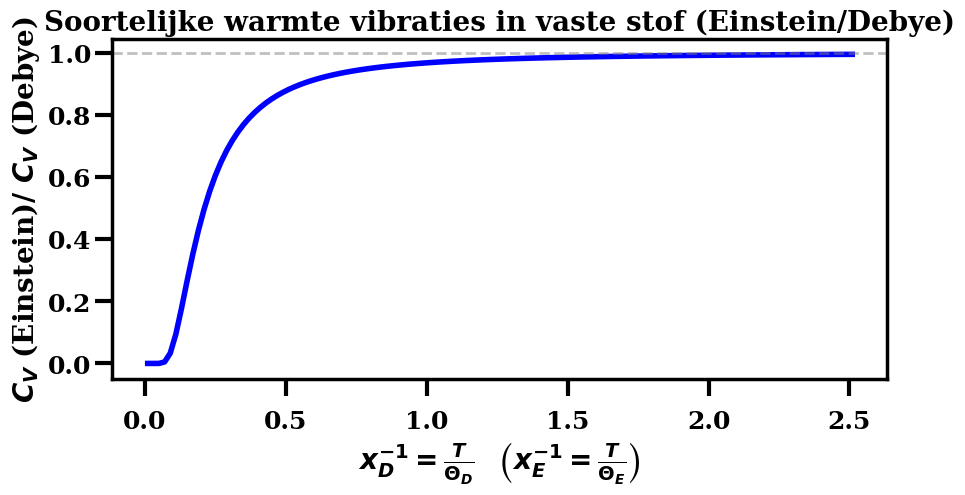

In [31]:
# create the plots for CV with mathplotlib
#
fig1=plt.figure(figsize=(10,5))
ax1=fig1.add_subplot(111)
fig1.subplots_adjust(bottom=0.2) # create room for x-axis label
#
# Figure 1: C_V / ( 3 N k) versus \frac{T}{\Theta_D} and versus \frac{T}{\Theta _E}

ax1.plot(TOVERTHETAD, CV3NK, "g-", linewidth=4, label=r'Debye theorie')
ax1.plot(TOVERTHETAD, CV3NK2, "r--", linewidth=4, label=r'Einstein theorie')
ax1.set_xlabel(r'$x_D^{-1} = \frac{T}{\Theta_D} \; \; \; \left(x_E^{-1} = \frac{T}{\Theta_E} \right)$', fontsize=20,fontweight='bold')
ax1.set_ylabel(r'$C_V$/(3Nk)', fontsize=20, fontweight='bold')
ax1.axhline(y=1.,color='grey',linestyle='dashed',alpha=0.5) #
#
# add a legend and a title
ax1.legend(frameon=False,fontsize=22,ncol=1,loc='best')
ax1.set_title(r'Soortelijke warmte vibraties in vaste stof (Einstein/Debye)', fontsize=20, fontweight='bold')
plt.show(fig1)
print(2*"\n")
#
# Figure 2: Verhouding C_V (Einstein) / C_V (Debye) versus T / Theta_D

fig2=plt.figure(figsize=(10,5))
ax2=fig2.add_subplot(111)
fig2.subplots_adjust(bottom=0.2) # create room for x-axis label
ax2.plot(TOVERTHETAD, CV3NK3, "b-", linewidth=4, label=r'Einstein/ Debye theorie')
ax2.set_xlabel(r'$x_D^{-1} = \frac{T}{\Theta_D} \; \; \; \left(x_E^{-1} = \frac{T}{\Theta_E} \right)$', fontsize=20, fontweight='bold')
ax2.set_ylabel(r'$C_V$ (Einstein)/ $C_V$ (Debye)', fontsize=20, fontweight='bold')
ax2.set_title(r'Soortelijke warmte vibraties in vaste stof (Einstein/Debye)', fontsize=20, fontweight='bold')
ax2.axhline(y=1.,color='grey',linestyle='dashed',alpha=0.5) #
plt.show(fig2)


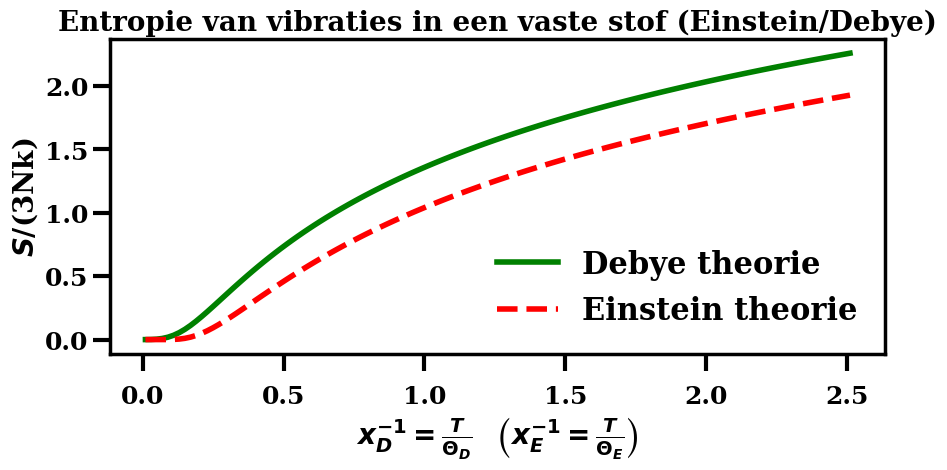

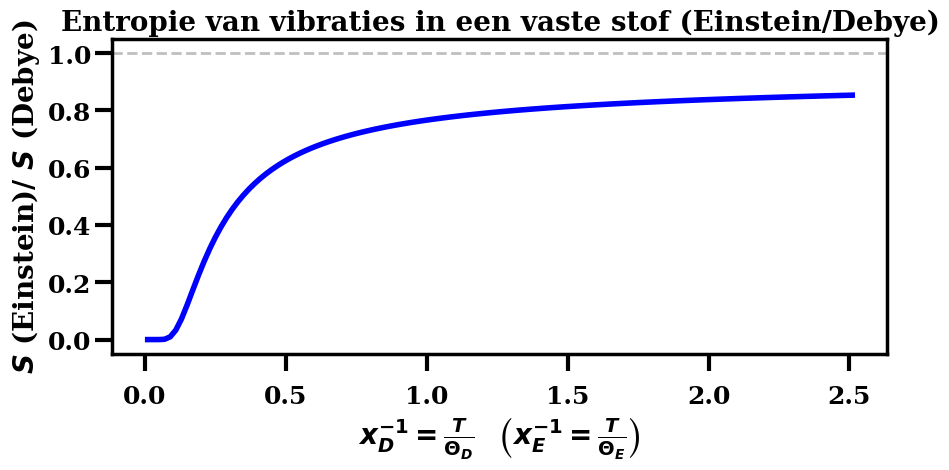

In [32]:
# create the plots for the entropy S with mathplotlib
#
fig3=plt.figure(figsize=(10,5))
ax3=fig3.add_subplot(111)
fig3.subplots_adjust(bottom=0.25) # create room for x-axis label

# Figure 3: S/ ( 3 N k) versus \frac{T}{\Theta_D} and versus \frac{T}{\Theta _E}

ax3.plot(TOVERTHETAD, S3NK, "g-", linewidth=4, label=r'Debye theorie')
ax3.plot(TOVERTHETAD, S3NK2, "r--", linewidth=4, label=r'Einstein theorie')
ax3.set_xlabel(r'$x_D^{-1} = \frac{T}{\Theta_D} \; \; \; \left(x_E^{-1} = \frac{T}{\Theta_E} \right)$', fontsize=20,fontweight='bold')
ax3.set_ylabel(r'$S$/(3Nk)', fontsize=20, fontweight='bold')
#
# add a legend and a title
ax3.legend(frameon=False,fontsize=22,ncol=1,loc='best')
ax3.set_title(r'Entropie van vibraties in een vaste stof (Einstein/Debye)', fontsize=20, fontweight='bold')
plt.show(fig3)
fig3.savefig('EntropyEinsteinDebye.eps',format='eps', dpi=1000)
print(2*"\n")

# Figure 4: Verhouding S (Einstein) / S (Debye) versus T / Theta_D

fig4=plt.figure(figsize=(10,5))
ax4=fig4.add_subplot(111)
fig4.subplots_adjust(bottom=0.25) # create room for x-axis label
ax4.plot(TOVERTHETAD, S3NK3, "b-", linewidth=4, label=r'Einstein/ Debye theorie')
ax4.set_xlabel(r'$x_D^{-1} = \frac{T}{\Theta_D} \; \; \; \left(x_E^{-1} = \frac{T}{\Theta_E} \right)$', fontsize=20, fontweight='bold')
ax4.set_ylabel(r'$S$ (Einstein)/ $S$ (Debye)', fontsize=20, fontweight='bold')
ax4.axhline(y=1.,color='grey',linestyle='dashed',alpha=0.5) #
ax4.set_title(r'Entropie van vibraties in een vaste stof (Einstein/Debye)', fontsize=20, fontweight='bold')
plt.show(fig4)
fig4.savefig('EntropyRatioEinsteinDebye.eps',format='eps', dpi=1000)
